In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context
from tqdm import tqdm
import os
from joblib import Parallel, delayed

import seaborn as sns
import pickle

from matplotlib import cm
import matplotlib.colors as mcolors

# Load features and labels

In [29]:
data = pd.read_pickle(r"..\..\results\gat\pooled_features_normalized_data.pkl")
labels = pd.read_pickle(r"..\..\results\gat\pooled_labels_normalized_data.pkl")
tissue_id = pd.read_pickle(r"..\..\results\gat\tissue_id.pkl")

In [30]:
adata = sc.AnnData(np.concatenate(data, axis=0))
adata.obs['labels'] = labels

In [31]:
sc.pp.neighbors(adata, n_neighbors=10)

c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
sc.tl.umap(adata)

In [33]:
sc.tl.leiden(adata, resolution=0.3)

C:\Users\zfang38\AppData\Local\Temp\ipykernel_61120\3347713724.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.3)


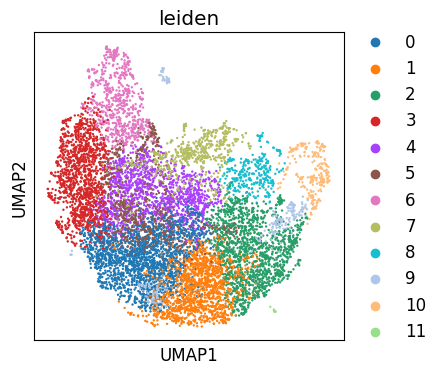

In [34]:
with rc_context({'figure.figsize': (4, 4), 'font.size':12, 'savefig.dpi':300}):
    sc.pl.umap(adata, color='leiden', save='_stromal_neighborhood_leiden.png')

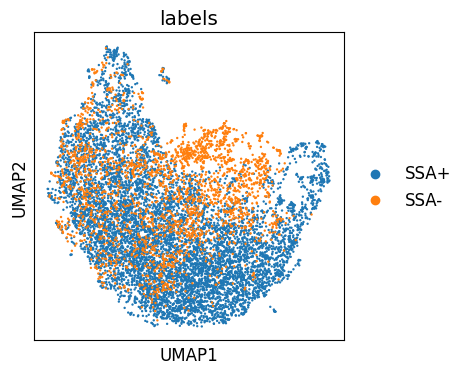

In [35]:
with rc_context({'figure.figsize':(4,4), 'font.size':12, 'savefig.dpi':300}):
    sc.pl.umap(adata, color='labels', save='_labels.png')

In [36]:
logit = pd.read_pickle(r'..\..\results\gat\logit_normalized_data.pkl')
logit = np.concatenate(logit, axis=0)

In [37]:
logit_diff = logit[:,1] - logit[:,0]

In [38]:
adata.obs['logit_diff'] = logit_diff

In [39]:
adata.obs.to_csv(r'..\..\results\gat\observation.csv')

In [ ]:
# observation = pd.read_csv(r'..\..\results\gat\observation.csv', index_col=0)

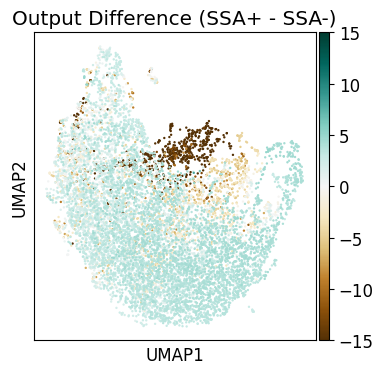

In [40]:
with rc_context({'figure.figsize':(4,4), 'font.size':12, 'savefig.dpi':300}):
    sc.pl.umap(adata, color='logit_diff', cmap='BrBG',vmin=-15, vmax=15, title='Output Difference (SSA+ - SSA-)', save='_logit_diff.png')

In [41]:
adata.obs['tissue_id'] = tissue_id

In [42]:
observation = adata.obs.copy()
groupby = observation.groupby('leiden')
mean_diff = groupby['logit_diff'].mean()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_61120\1916048037.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby = observation.groupby('leiden')


In [43]:
observation['leiden'].value_counts()

leiden
0     1920
1     1448
2     1430
3     1349
4     1330
5      774
6      663
7      539
8      318
9      264
10     249
11       8
Name: count, dtype: int64

In [44]:
adata.write_h5ad(r'..\..\results\gat\gat_.csv')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\1971813806.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('BrBG')
C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\1971813806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, ax=ax, palette=colors)


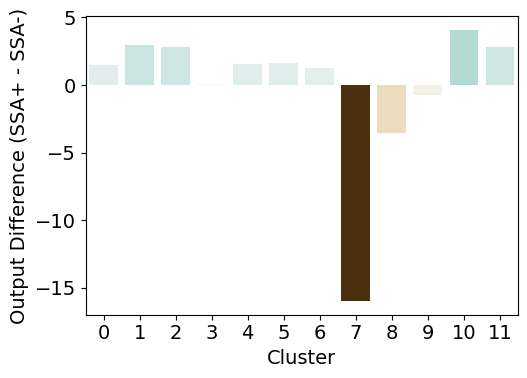

In [63]:
with rc_context({'font.size': 14}):
    fig, ax = plt.subplots(figsize=(5.5,4))
    temp = mean_diff.sort_index()
    
    norm = mcolors.TwoSlopeNorm(vmin=-15, vcenter=0, vmax=15)
    cmap = cm.get_cmap('BrBG')
    colors = [cmap(norm(value)) for value in temp.values]

    sns.barplot(x=temp.index, y=temp.values, ax=ax, palette=colors)
    ax.set_xlim(-0.5,11.5)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Output Difference (SSA+ - SSA-)')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\mean_logit_diff_per_cluster_full.png', dpi=300)
    plt.show()

# Cluster composition

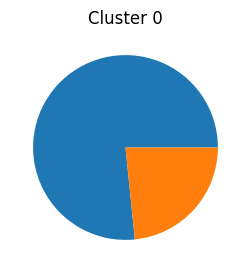

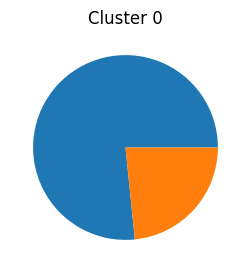

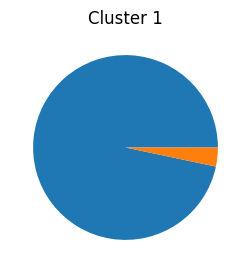

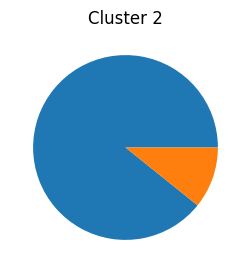

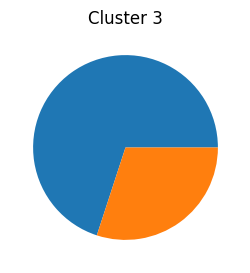

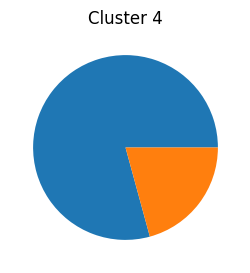

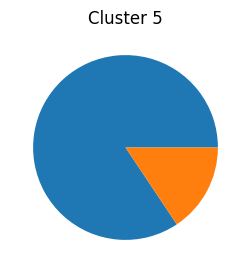

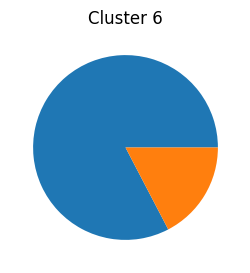

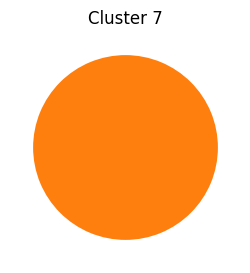

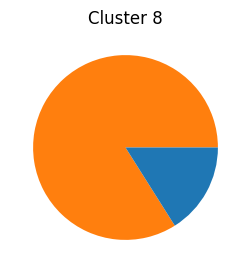

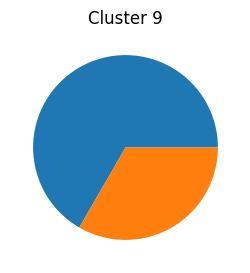

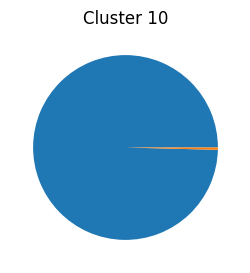

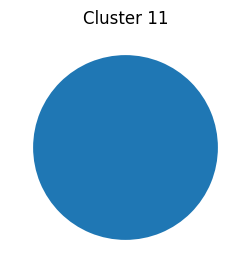

In [53]:
for i in range(12):
    cluster = adata.obs['leiden'].cat.categories[i]
    temp = observation[observation['leiden'] == cluster].copy()
    with rc_context({'figure.figsize': (3, 3), 'font.size': 10}):
        fig, ax = plt.subplots()
        temp['labels'].value_counts().plot.pie(
            ax = ax, 
            fontsize=10,
            colors=['#1f77b4' if label == 'SSA+' else '#ff7f0e' for label in temp['labels'].value_counts().index],
            labels=None,
            title=f'Cluster {cluster}'
        )
        ax.set_ylabel('')
        plt.savefig(f'..\\..\\figures\\gat\\cluster_composition\\cluster_{cluster}_ssa_count.png')
        plt.show()

In [92]:
# donor count of each cluster
colors = {'83': '#1f77b4', '134': '#559bd0', '141': '#ff7f0e', '126-1': '#ffa54c',
         '126-2': '#2ca02c', '7223-1': '#58c758', '7223-2': '#d62728'}

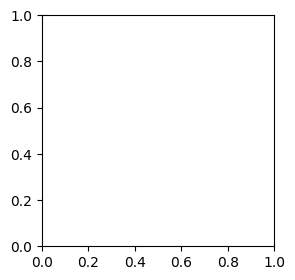

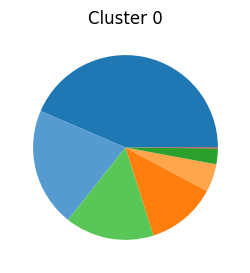

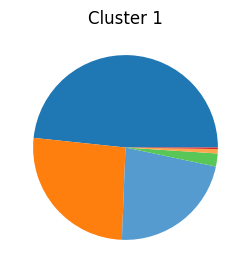

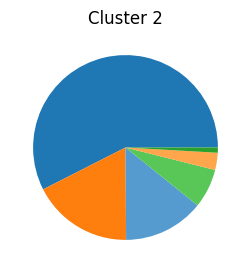

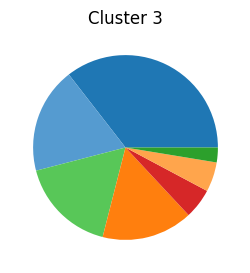

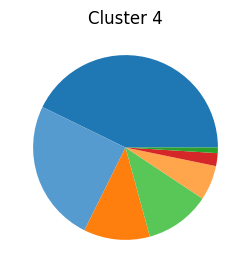

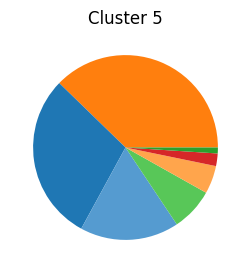

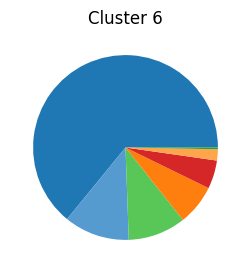

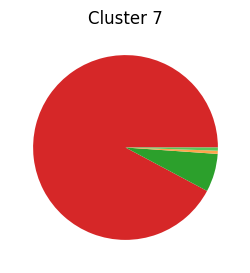

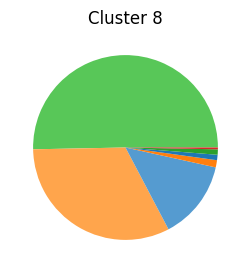

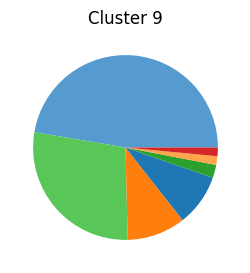

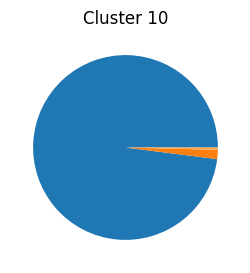

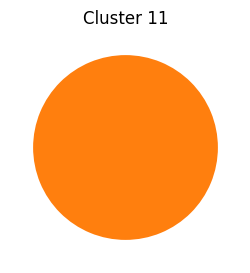

In [62]:
for i in range(12):
    cluster = adata.obs['leiden'].cat.categories[i]
    temp = observation[observation['leiden'] == cluster].copy()
    with rc_context({'figure.figsize': (3, 3), 'font.size': 10}):
        fig, ax = plt.subplots()
        tissue_count = temp['tissue_id'].value_counts()
        tissue_count.plot.pie(
            ax = ax,
            fontsize=10,
            colors=[colors[tissue] for tissue in tissue_count.index],
            title=f'Cluster {cluster}',
            labels=None
        )
        ax.set_ylabel('')
        plt.savefig(f'..\\..\\figures\\gat\\cluster_composition\\cluster_{cluster}_tissue_count.png')
        plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\2894071564.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp['tissue_id'].replace({'126-1':'Donor 7-1', '126-2':'Donor 7-2', '7223-1':'Donor 12-1', '7223-2':'Donor 12-2', '83':'Donor 1', '134': 'Donor 6', '141': 'Donor 10'}, inplace=True)


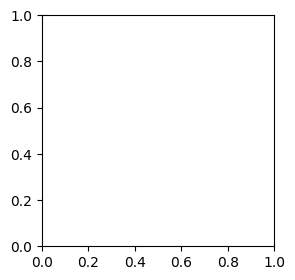

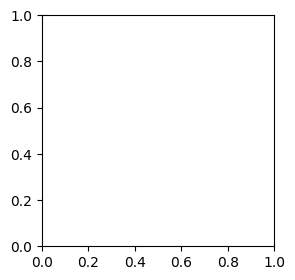

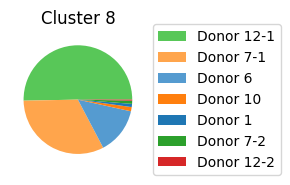

In [97]:
# donor count of each cluster
colors = {'Donor 1': '#1f77b4', 'Donor 6': '#559bd0', 'Donor 10': '#ff7f0e', 'Donor 7-1': '#ffa54c',
         'Donor 7-2': '#2ca02c', 'Donor 12-1': '#58c758', 'Donor 12-2': '#d62728'}
cluster = adata.obs['leiden'].cat.categories[8]
temp = observation[observation['leiden'] == cluster].copy()
temp['tissue_id'].replace({'126-1':'Donor 7-1', '126-2':'Donor 7-2', '7223-1':'Donor 12-1', '7223-2':'Donor 12-2', '83':'Donor 1', '134': 'Donor 6', '141': 'Donor 10'}, inplace=True)
with rc_context({'figure.figsize': (3, 3), 'font.size': 10}):
    fig, ax = plt.subplots()
    tissue_count = temp['tissue_id'].value_counts()
    tissue_count.plot.pie(
        ax = ax,
        fontsize=10,
        colors=[colors[tissue] for tissue in tissue_count.index],
        title=f'Cluster {cluster}',
        labels=None
    )
    ax.legend(labels=tissue_count.index, loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(f'..\\..\\figures\\gat\\cluster_composition\\cluster_{cluster}_tissue_count_legend.png')
    plt.show()

In [89]:
temp

,labels,leiden,logit_diff,tissue_id
2855,SSA+,8,4.811378,83
2890,SSA+,8,4.811378,83
3938,SSA+,8,5.135612,83
4578,SSA+,8,-0.455903,134
4589,SSA+,8,-0.566479,134
...,...,...,...,...
9626,SSA-,8,-0.445556,7223-1
9629,SSA-,8,-0.942735,7223-1
9630,SSA-,8,-0.445556,7223-1
9631,SSA-,8,-4.014243,7223-1


C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\2736981537.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('BrBG')
C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\2736981537.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(0,9), y=temp.values, ax=ax, palette=colors)
C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\2736981537.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(temp.index)


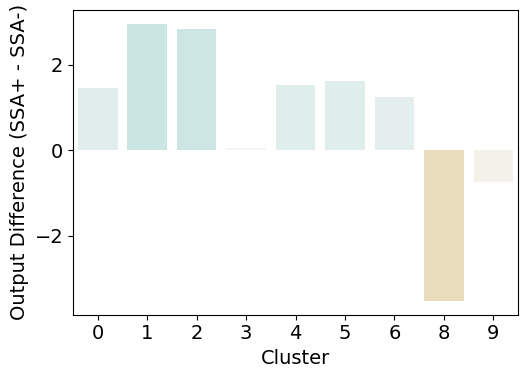

In [70]:
with rc_context({'font.size': 14}):
    fig, ax = plt.subplots(figsize=(5.5,4))
    temp = mean_diff.iloc[[0,1,2,3,4,5,6,8,9]]
    
    norm = mcolors.TwoSlopeNorm(vmin=-15, vcenter=0, vmax=15)
    cmap = cm.get_cmap('BrBG')
    colors = [cmap(norm(value)) for value in temp.values]

    sns.barplot(x=np.arange(0,9), y=temp.values, ax=ax, palette=colors)
    ax.set_xticklabels(temp.index)
    ax.set_xlim(-0.5,8.5)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Output Difference (SSA+ - SSA-)')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\mean_logit_diff_per_cluster_selected.png', dpi=300)
    plt.show()

## cell type composition

In [8]:
if_adata = sc.read_h5ad(r'..\..\results\singleCell\IF.h5ad')

In [9]:
if_adata

AnnData object with n_obs × n_vars = 228642 × 11
    obs: 'Condition', 'Sample', 'leiden', 'RO52', 'RO60', 'Lymphocyte', 'Ro52_raw', 'Ro60_raw', 'Ro52_scanorama', 'Ro60_scanorama'
    uns: 'Condition_colors', 'Lymphocyte_colors', 'dendrogram_leiden', 'leiden', 'leiden_colors', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'

In [10]:
cell_type_colors = {}
for l in if_adata.obs['leiden'].cat.categories:
    cell_type_colors[l] = if_adata.uns['leiden_colors'][int(l)]

In [11]:
graphs_83 = pd.read_pickle(r'..\..\results\gat\sub_graphs_83.pkl')
graphs_83 = [graph for graph in graphs_83 if len(graph) > 0]
graphs_134 = pd.read_pickle(r'..\..\results\gat\sub_graphs_134.pkl')
graphs_134 = [graph for graph in graphs_134 if len(graph) > 0]
graphs_141 = pd.read_pickle(r'..\..\results\gat\sub_graphs_141.pkl')
graphs_141 = [graph for graph in graphs_141 if len(graph) > 0]
graphs_1261 = pd.read_pickle(r'..\..\results\gat\sub_graphs_1261.pkl')
graphs_1261 = [graph for graph in graphs_1261 if len(graph) > 0]
graphs_1262 = pd.read_pickle(r'..\..\results\gat\sub_graphs_1262.pkl')
graphs_1262 = [graph for graph in graphs_1262 if len(graph) > 0]
graphs_72231 = pd.read_pickle(r'..\..\results\gat\sub_graphs_72231.pkl')
graphs_72231 = [graph for graph in graphs_72231 if len(graph) > 0]
graphs_72232 = pd.read_pickle(r'..\..\results\gat\sub_graphs_72232.pkl')
graphs_72232 = [graph for graph in graphs_72232 if len(graph) > 0]

In [12]:
temp = list(np.unique(graphs_83[0]))
temp = ['83_' + str(int(i)) for i in temp]

In [13]:
def count_neighborhood(neighborhood, annotation, tissue):
    unique_cells = list(np.unique(neighborhood))
    unique_cells = [tissue + '_' + str(int(i)) for i in unique_cells]
    unique_cells = [cell for cell in unique_cells if cell in annotation.index]
    cell_types = annotation.loc[unique_cells]['leiden']
    return cell_types.value_counts()

In [14]:
cell_type_counts = {}
for cell in cell_type_colors.keys():
    cell_type_counts[cell] = []

if_observation = if_adata.obs.copy()

for item in tqdm(graphs_83):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='83'], '83')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

for item in tqdm(graphs_134):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='134'], '134')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

for item in tqdm(graphs_141):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='141'], '141')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

for item in tqdm(graphs_1261):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='1261'], '1261')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

for item in tqdm(graphs_1262):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='1262'], '1262')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

for item in tqdm(graphs_72231):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='72231'], '72231')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

for item in tqdm(graphs_72232):
    temp = count_neighborhood(item, if_observation[if_observation['Sample']=='72232'], '72232')
    for cell in cell_type_colors.keys():
        if cell in temp.index:
            cell_type_counts[cell].append(temp[cell])
        else:
            cell_type_counts[cell].append(0)

100%|██████████| 660/660 [00:00<00:00, 790.05it/s]


In [15]:
cell_composition = pd.DataFrame(cell_type_counts)
cell_composition.columns = cell_type_counts.keys()

In [16]:
cell_composition = cell_composition/cell_composition.sum(axis=1).values[:,None]

In [45]:
cell_composition['cluster'] = adata.obs['leiden'].tolist()

In [46]:
mean_composition = cell_composition.groupby('cluster').mean()

In [47]:
cell_composition

,0,1,2,3,4,5,6,7,8,9,10,11,12,cluster
0,0.538462,0.000000,0.076923,0.230769,0.153846,0.0,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,1
1,0.307692,0.000000,0.384615,0.230769,0.000000,0.0,0.000000,0.076923,0.0,0.000,0.0,0.0,0.0,3
2,0.636364,0.000000,0.090909,0.090909,0.181818,0.0,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,3
3,0.692308,0.000000,0.076923,0.230769,0.000000,0.0,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,1
4,0.875000,0.000000,0.125000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10287,0.000000,0.307692,0.153846,0.461538,0.000000,0.0,0.076923,0.000000,0.0,0.000,0.0,0.0,0.0,7
10288,0.000000,0.384615,0.538462,0.076923,0.000000,0.0,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,7
10289,0.916667,0.000000,0.083333,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,3
10290,0.000000,0.625000,0.250000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.125,0.0,0.0,0.0,5


In [ ]:
# cell_composition.to_csv(r'..\..\results\gat\cell_composition_per_neighborhood.csv')

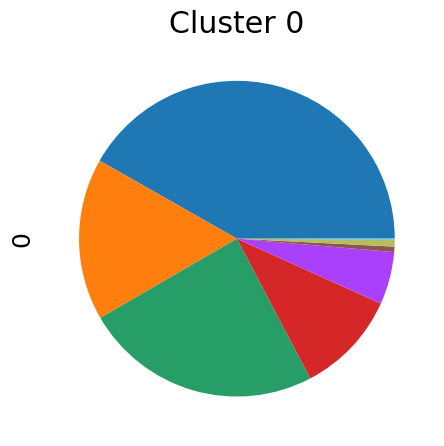

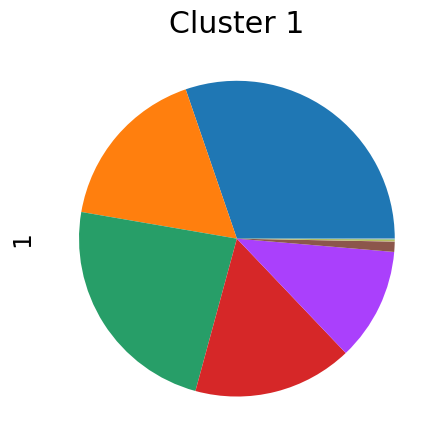

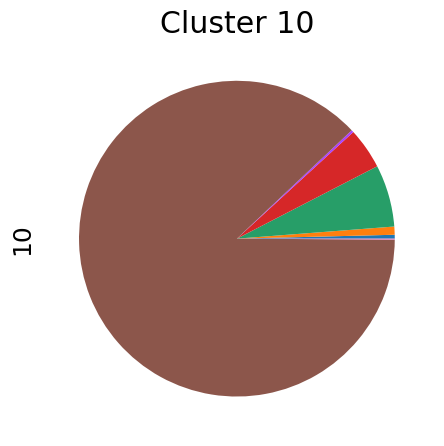

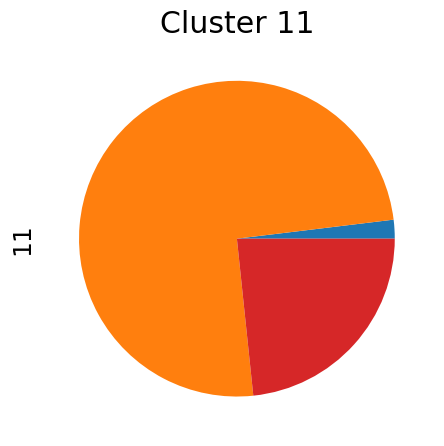

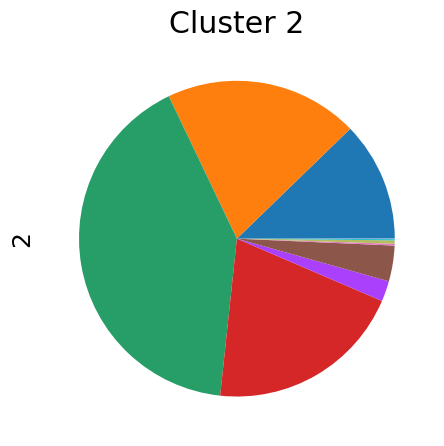

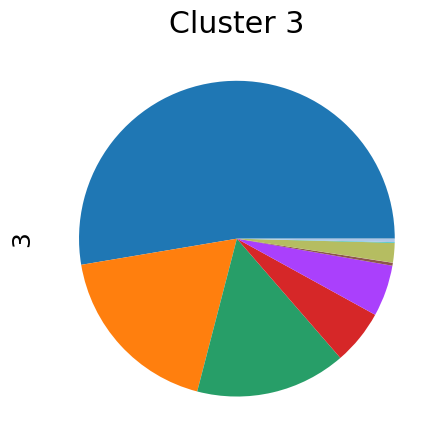

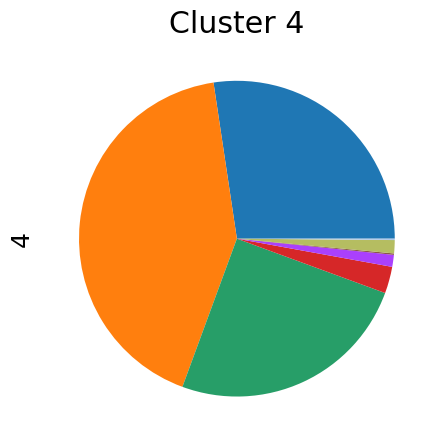

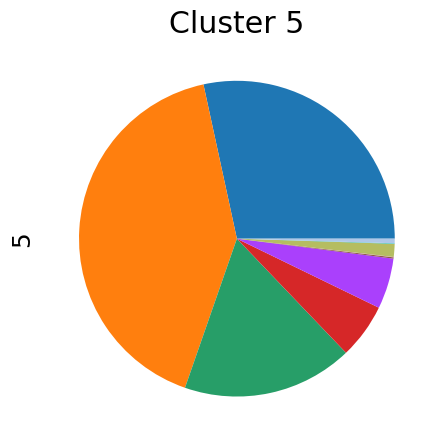

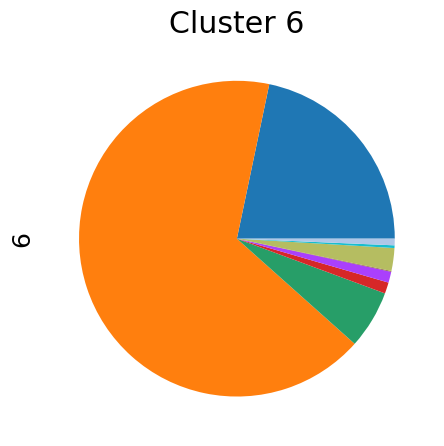

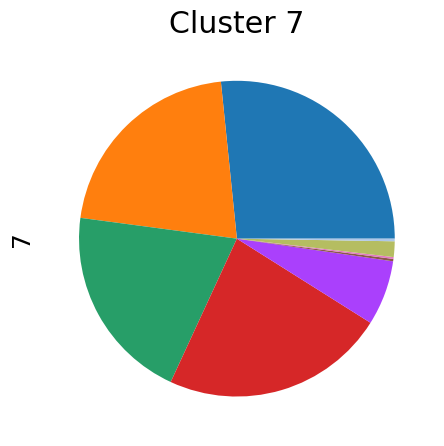

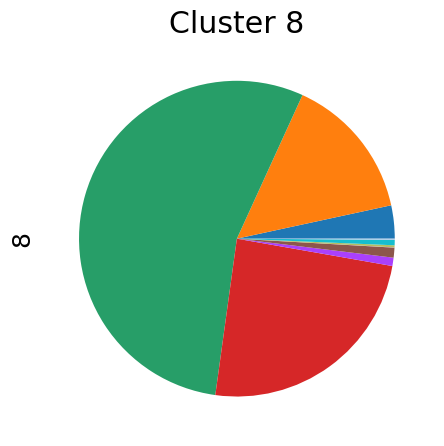

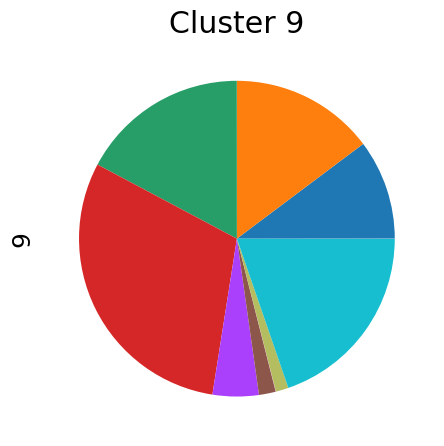

In [133]:
for item in mean_composition.index:
    with rc_context({'font.size':18}):
        mean_composition.loc[item].plot.pie(
            colors=[cell_type_colors[cell] for cell in mean_composition.columns],
            legend=False,
            title=f'Cluster {item}',
            labels=None  # Remove labels from each wedge
        )
        plt.tight_layout()
        plt.savefig(f'..\\..\\figures\\gat\\cluster_composition\\cluster_{item}_cell_type_composition.png')
        plt.show()

In [142]:
mapper = {'0': 'KRT14, KRT7, KRT5','1':'CD4, CD8', '2':'COL1', '3':'AQP5,KRT14,KRT7', '4':'AQP5, KRT7 low', 
          '5':'COL1, KRT14 low', '6':'KI67, COL1', '7':'CD20, KI67', '8':'CD21, KI67',
          '9':'CD68', '10':'KRT5, KRT7 and KRT14 low', '11':'KI67, CD8, CD68', '12':'COL1, CD68 low'}

In [143]:
cluster_colors = {mapper.get(k, k): v for k, v in cell_type_colors.items()}

In [151]:
mean_composition.rename(columns=mapper, inplace=True)

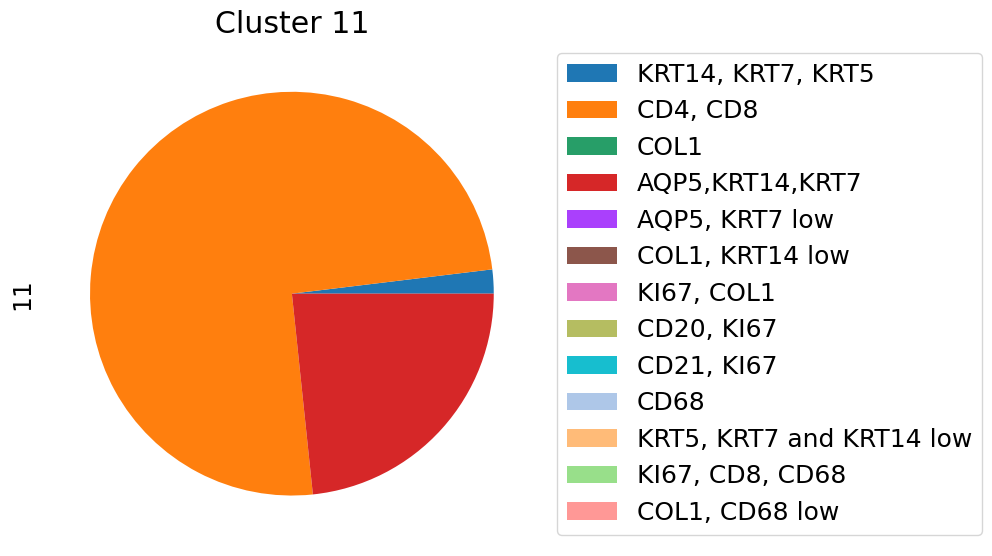

In [158]:
item = mean_composition.index[3]
with rc_context({'font.size':18, 'figure.figsize':(12,6)}):
    mean_composition.loc[item].plot.pie(
        colors=[cluster_colors[cell] for cell in mean_composition.columns],
        legend=False,
        title=f'Cluster {item}',
        labels=None  # Remove labels from each wedge
    )
    plt.legend(labels=mean_composition.columns.tolist(), loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.savefig(f'..\\..\\figures\\gat\\cluster_composition\\cluster_{item}_cell_type_composition_legend.png')
    plt.show()

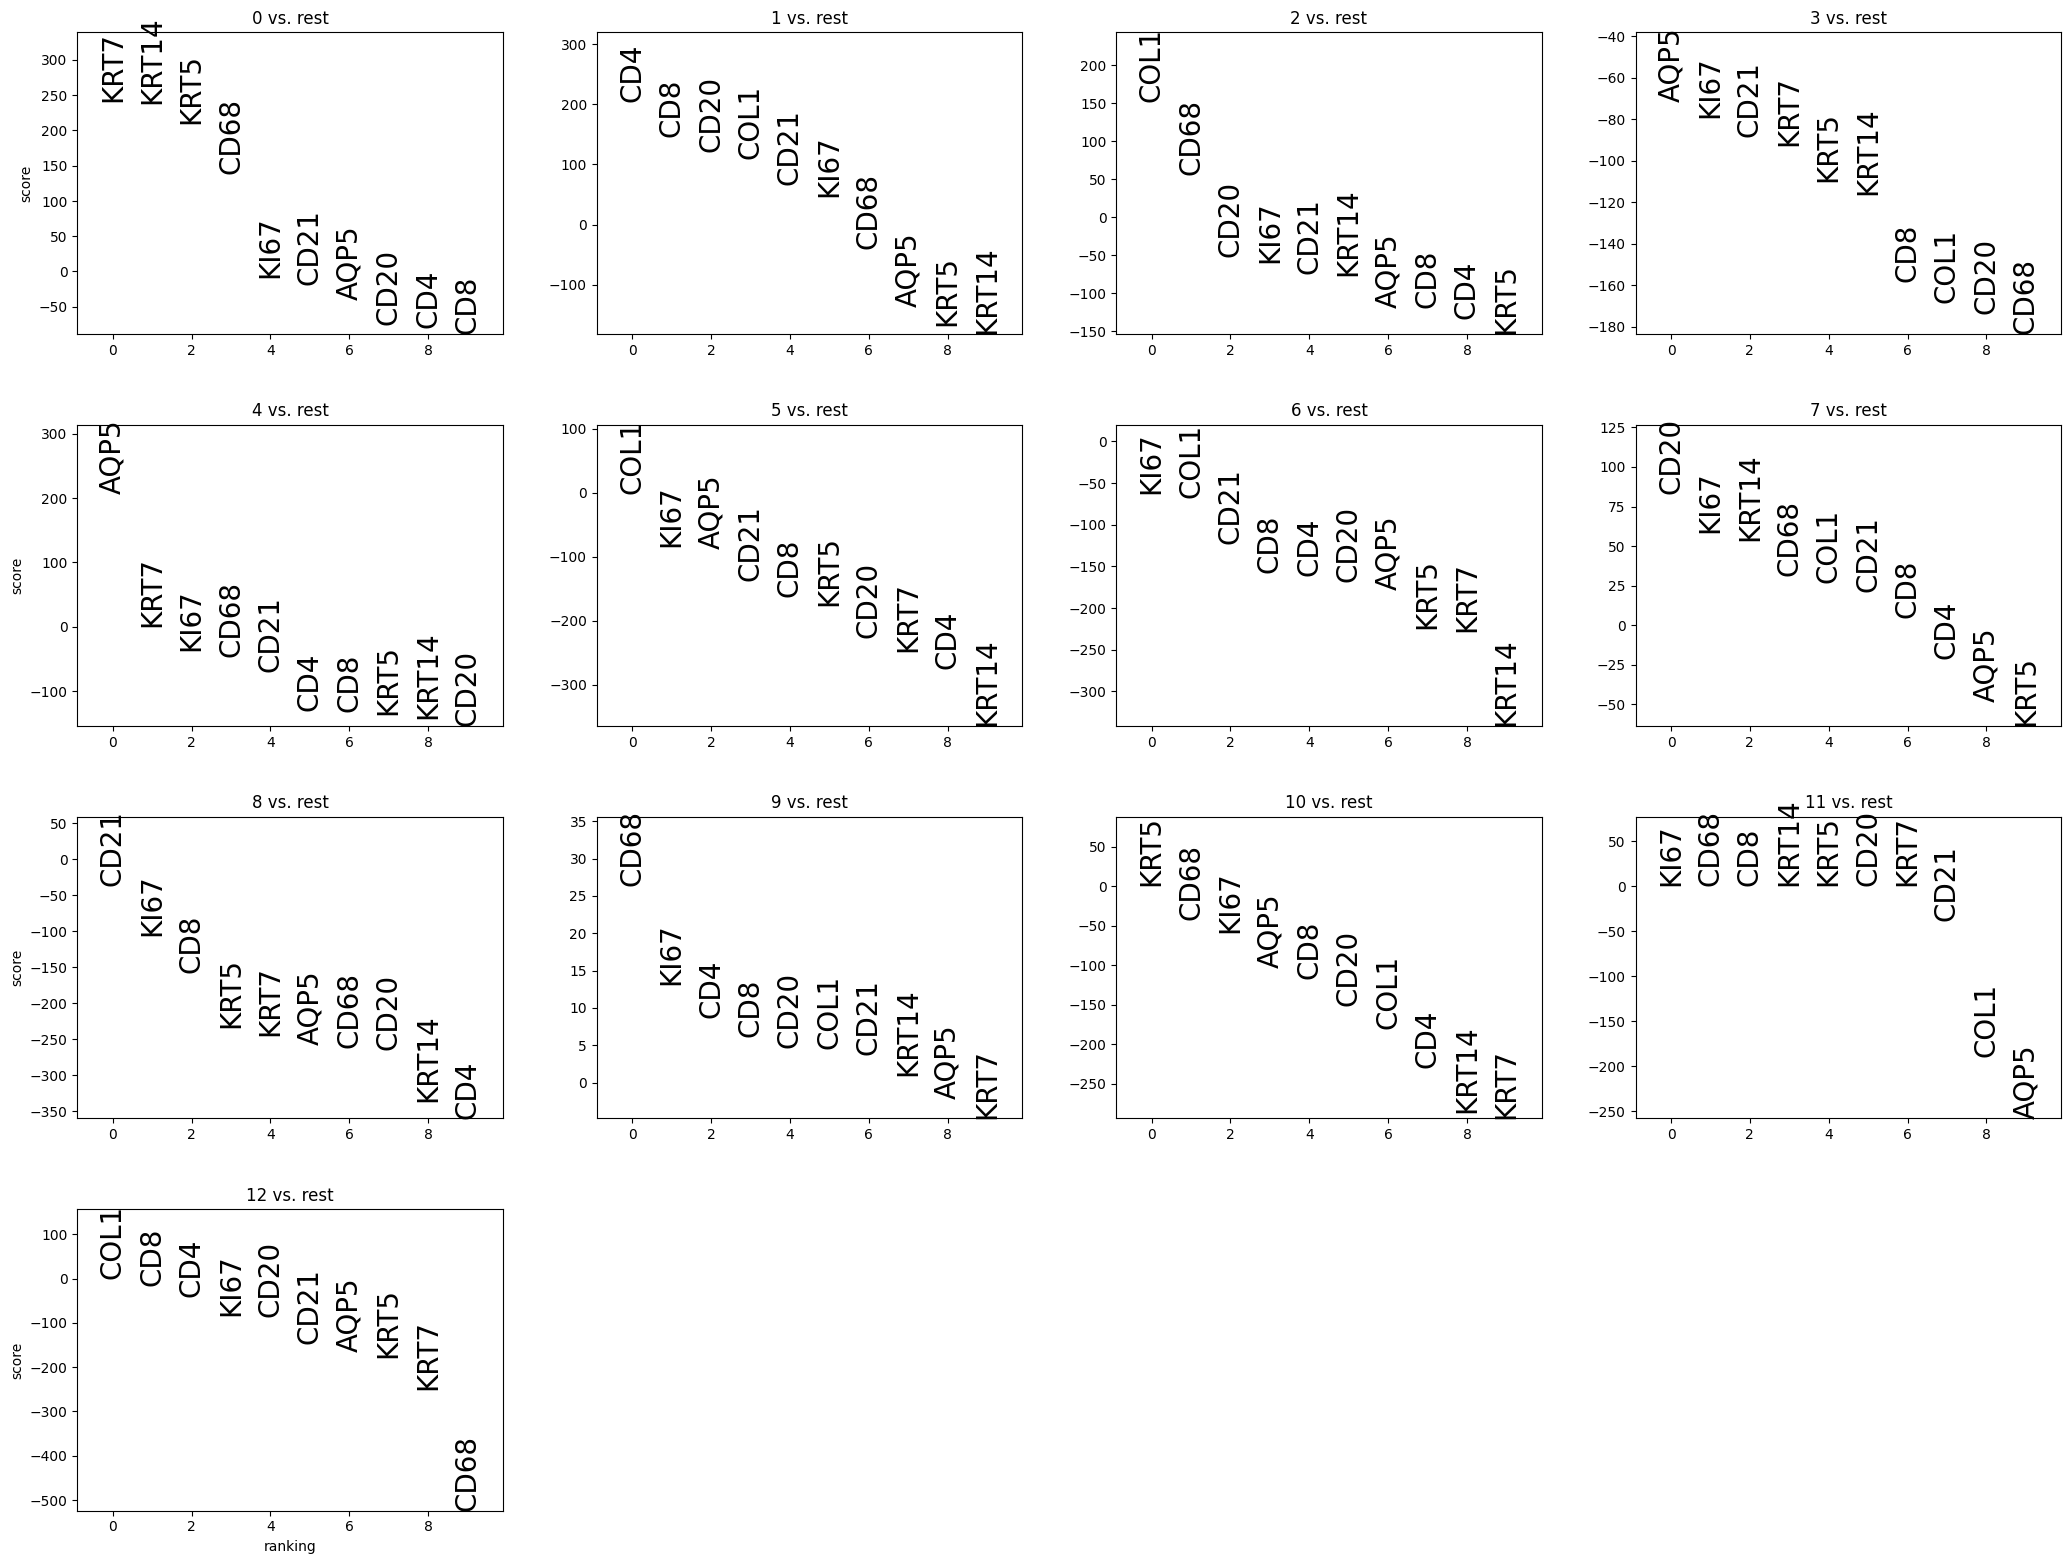

In [141]:
sc.pl.rank_genes_groups(if_adata, n_genes=10, sharey=False, fontsize=20)

# mean ro proein expression

In [19]:
if_adata.obs

,Condition,Sample,leiden,RO52,RO60,Lymphocyte,Ro52_raw,Ro60_raw,Ro52_scanorama,Ro60_scanorama
83_5,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_7,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_9,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_11,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_16,SSA+,83,1,-0.217449,-0.159062,Lymphocyte,0.000000,0.000000,0.056597,0.066960
...,...,...,...,...,...,...,...,...,...,...
1262_2742,SSA-,1262,2,0.744606,0.461298,Lymphocyte,5.769777,7.348884,0.272150,0.285676
1262_2743,SSA-,1262,1,0.622301,1.022701,Lymphocyte,5.467674,11.358522,0.269879,0.447779
1262_2744,SSA-,1262,1,0.031466,0.334921,Lymphocyte,4.008264,6.446281,0.194204,0.226247
1262_2745,SSA-,1262,2,1.111835,0.327734,Lymphocyte,6.676862,6.394947,0.329209,0.267366


In [24]:
def neighborhood_ro(neighborhood, annotation, tissue):
    unique_cells = list(np.unique(neighborhood))
    unique_cells = [tissue + '_' + str(int(i)) for i in unique_cells]
    unique_cells = [cell for cell in unique_cells if cell in annotation.index]
    ro52 = annotation.loc[unique_cells]['Ro52_scanorama']
    ro60 = annotation.loc[unique_cells]['Ro60_scanorama']
    return [ro52.mean(), ro60.mean()]

In [25]:
neighborhood_ro(graphs_83[0], if_adata.obs[if_adata.obs['Sample']=='83'], '83')

[np.float64(0.11110736225787562), np.float64(0.1033086878794476)]

In [26]:
neighborhood_ro_mean = []
for item in tqdm(graphs_83):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='83'], '83')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_134):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='134'], '134')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_141):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='141'], '141')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_1261):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='1261'], '1261')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_1262):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='1262'], '1262')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_72231):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='72231'], '72231')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_72232):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='72232'], '72232')
    neighborhood_ro_mean.append(temp)

100%|██████████| 660/660 [00:00<00:00, 817.40it/s]


In [27]:
neighborhood_ro_mean = pd.DataFrame(neighborhood_ro_mean, columns=['Ro52', 'Ro60'])

In [48]:
neighborhood_ro_mean['cluster'] = adata.obs['leiden'].tolist()

In [49]:
stats_ro52 = pd.DataFrame({'Expression': neighborhood_ro_mean['Ro52'].tolist(), 'Marker':'Ro52','Cluster': neighborhood_ro_mean['cluster'].astype(int)})
stats_ro52.sort_values(by=['Cluster'], inplace=True)
stats_ro60 = pd.DataFrame({'Expression': neighborhood_ro_mean['Ro60'].tolist(), 'Marker':'Ro60','Cluster': neighborhood_ro_mean['cluster'].astype(int)})
stats_ro60.sort_values(by=['Cluster'], inplace=True)

C:\Users\zfang38\AppData\Local\Temp\ipykernel_61120\3205105357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_ro52, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)


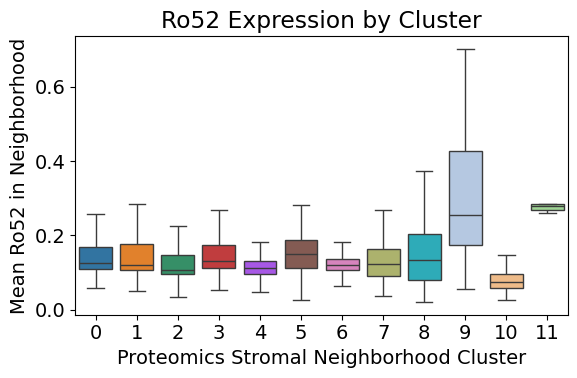

In [56]:
with rc_context({'figure.figsize':(6,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=stats_ro52, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.xlabel('Proteomics Stromal Neighborhood Cluster')
    plt.ylabel('Mean Ro52 in Neighborhood')
    plt.title('Ro52 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro52_expression_by_cluster_scanorama.png')
    plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_61120\2769132875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_ro52, x='Cluster', y='Expression', palette=colors, showfliers=False)


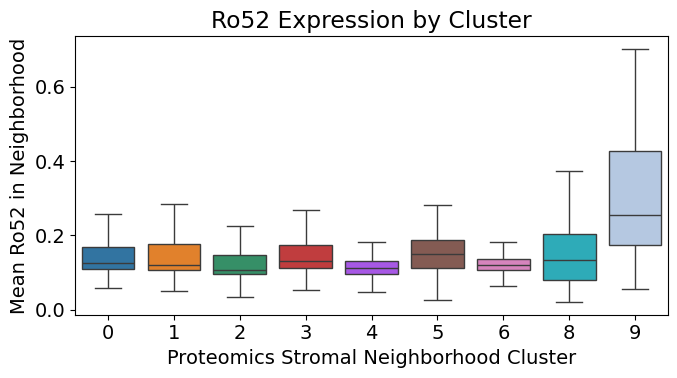

In [57]:
filtered_ro52 = stats_ro52[stats_ro52['Cluster'].isin([0,1,2,3,4,5,6,8,9])]
colors = [adata.uns['leiden_colors'][i] for i in [0,1,2,3,4,5,6,8,9]]
with rc_context({'figure.figsize':(7,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=filtered_ro52, x='Cluster', y='Expression', palette=colors, showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro52 in Neighborhood')
    plt.xlabel('Proteomics Stromal Neighborhood Cluster')
    plt.title('Ro52 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro52_expression_by_cluster_selected_scanorama.png')
    plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_61120\1249906842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_ro60, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)


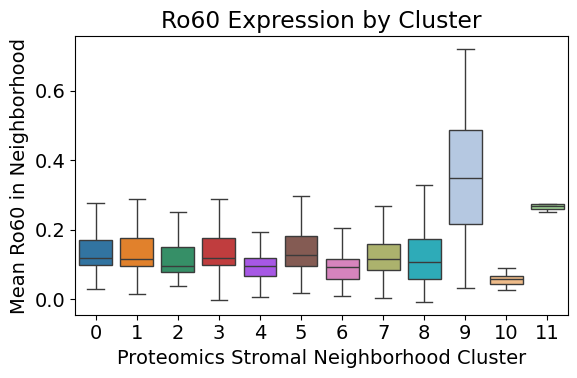

In [58]:
with rc_context({'figure.figsize':(6,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=stats_ro60, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro60 in Neighborhood')
    plt.xlabel('Proteomics Stromal Neighborhood Cluster')
    plt.title('Ro60 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro60_expression_by_cluster_scanorama.png')
    plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_61120\3844738924.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_ro60, x='Cluster', y='Expression', palette=colors, showfliers=False)


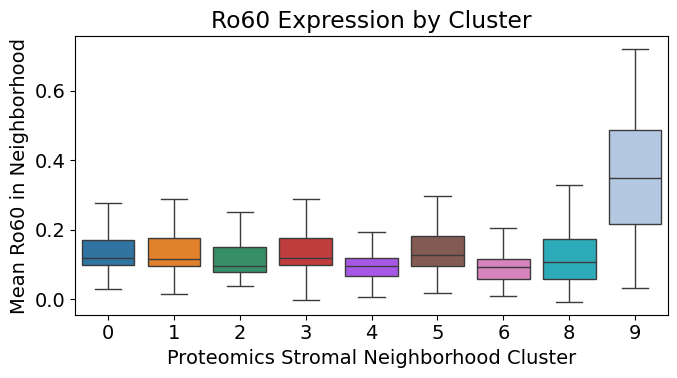

In [59]:
filtered_ro60 = stats_ro60[stats_ro60['Cluster'].isin([0,1,2,3,4,5,6,8,9])]
colors = [adata.uns['leiden_colors'][i] for i in [0,1,2,3,4,5,6,8,9]]
with rc_context({'figure.figsize':(7,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=filtered_ro60, x='Cluster', y='Expression', palette=colors, showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro60 in Neighborhood')
    plt.xlabel('Proteomics Stromal Neighborhood Cluster')
    plt.title('Ro60 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro60_expression_by_cluster_selected_scanorama.png')
    plt.show()

# mean ro proein expression scanorama normalized expression

In [6]:
if_exp = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\ssa_if_analysis\results\singleCell\if_scanorama.csv')

In [18]:
if_adata.obs

,Condition,Sample,leiden,RO52,RO60,Lymphocyte,Ro52_raw,Ro60_raw,Ro52_scanorama,Ro60_scanorama
83_5,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_7,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_9,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_11,SSA+,83,12,-0.217449,-0.159062,Non-lymphocyte,0.000000,0.000000,0.056534,0.035531
83_16,SSA+,83,1,-0.217449,-0.159062,Lymphocyte,0.000000,0.000000,0.056597,0.066960
...,...,...,...,...,...,...,...,...,...,...
1262_2742,SSA-,1262,2,0.744606,0.461298,Lymphocyte,5.769777,7.348884,0.272150,0.285676
1262_2743,SSA-,1262,1,0.622301,1.022701,Lymphocyte,5.467674,11.358522,0.269879,0.447779
1262_2744,SSA-,1262,1,0.031466,0.334921,Lymphocyte,4.008264,6.446281,0.194204,0.226247
1262_2745,SSA-,1262,2,1.111835,0.327734,Lymphocyte,6.676862,6.394947,0.329209,0.267366


In [ ]:
def neighborhood_ro(neighborhood, annotation, tissue):
    unique_cells = list(np.unique(neighborhood))
    unique_cells = [tissue + '_' + str(int(i)) for i in unique_cells]
    unique_cells = [cell for cell in unique_cells if cell in annotation.index]
    ro52 = annotation.loc[unique_cells]['RO52']
    ro60 = annotation.loc[unique_cells]['RO60']
    return [ro52.mean(), ro60.mean()]

In [ ]:
neighborhood_ro(graphs_83[0], if_adata.obs[if_adata.obs['Sample']=='83'], '83')

[np.float64(-0.018360927792152787), np.float64(0.28767029484696327)]

In [ ]:
neighborhood_ro_mean = []
for item in tqdm(graphs_83):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='83'], '83')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_134):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='134'], '134')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_141):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='141'], '141')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_1261):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='1261'], '1261')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_1262):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='1262'], '1262')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_72231):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='72231'], '72231')
    neighborhood_ro_mean.append(temp)

for item in tqdm(graphs_72232):
    temp = neighborhood_ro(item, if_adata.obs[if_adata.obs['Sample']=='72232'], '72232')
    neighborhood_ro_mean.append(temp)

100%|██████████| 660/660 [00:00<00:00, 842.45it/s]


In [ ]:
neighborhood_ro_mean = pd.DataFrame(neighborhood_ro_mean, columns=['Ro52', 'Ro60'])

In [ ]:
neighborhood_ro_mean['cluster'] = adata.obs['leiden'].tolist()

In [ ]:
stats_ro52 = pd.DataFrame({'Expression': neighborhood_ro_mean['Ro52'].tolist(), 'Marker':'Ro52','Cluster': neighborhood_ro_mean['cluster'].astype(int)})
stats_ro52.sort_values(by=['Cluster'], inplace=True)
stats_ro60 = pd.DataFrame({'Expression': neighborhood_ro_mean['Ro60'].tolist(), 'Marker':'Ro60','Cluster': neighborhood_ro_mean['cluster'].astype(int)})
stats_ro60.sort_values(by=['Cluster'], inplace=True)

C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\3079384213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_ro52, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)
C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\3079384213.py:2: UserWarning: The palette list has more values (16) than needed (12), which may not be intended.
  sns.boxplot(data=stats_ro52, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)


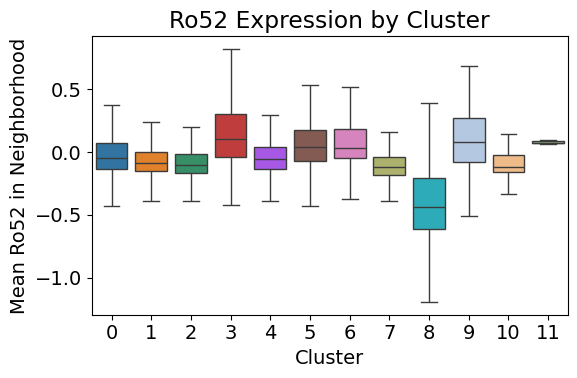

In [ ]:
with rc_context({'figure.figsize':(6,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=stats_ro52, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro52 in Neighborhood')
    plt.title('Ro52 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro52_expression_by_cluster.png')
    plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\737734125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_ro52, x='Cluster', y='Expression', palette=colors, showfliers=False)


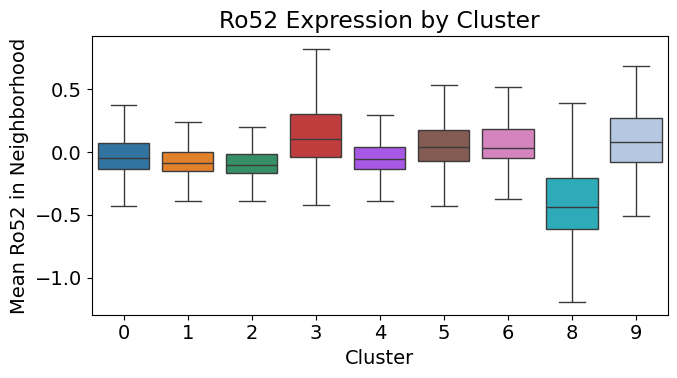

In [ ]:
filtered_ro52 = stats_ro52[stats_ro52['Cluster'].isin([0,1,2,3,4,5,6,8,9])]
colors = [adata.uns['leiden_colors'][i] for i in [0,1,2,3,4,5,6,8,9]]
with rc_context({'figure.figsize':(7,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=filtered_ro52, x='Cluster', y='Expression', palette=colors, showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro52 in Neighborhood')
    plt.title('Ro52 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro52_expression_by_cluster_selected.png')
    plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\116904220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_ro60, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)
C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\116904220.py:2: UserWarning: The palette list has more values (16) than needed (12), which may not be intended.
  sns.boxplot(data=stats_ro60, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)


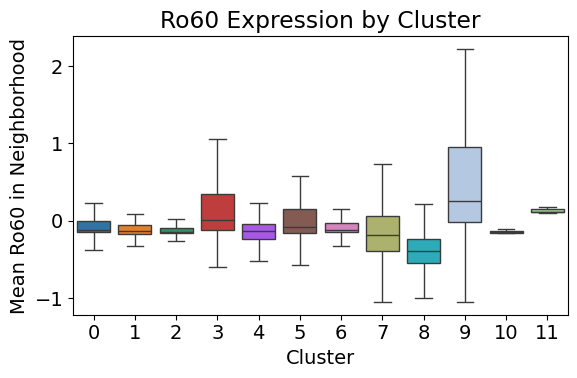

In [ ]:
with rc_context({'figure.figsize':(6,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=stats_ro60, x='Cluster', y='Expression', palette=adata.uns['leiden_colors'], showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro60 in Neighborhood')
    plt.title('Ro60 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro60_expression_by_cluster.png')
    plt.show()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_93308\3899831609.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_ro60, x='Cluster', y='Expression', palette=colors, showfliers=False)


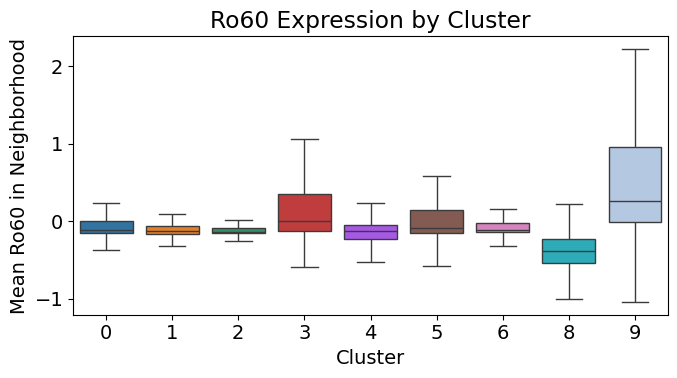

In [ ]:
filtered_ro60 = stats_ro60[stats_ro60['Cluster'].isin([0,1,2,3,4,5,6,8,9])]
colors = [adata.uns['leiden_colors'][i] for i in [0,1,2,3,4,5,6,8,9]]
with rc_context({'figure.figsize':(7,4), 'font.size':14, 'savefig.dpi':300}):
    sns.boxplot(data=filtered_ro60, x='Cluster', y='Expression', palette=colors, showfliers=False)
    # sns.stripplot(data=stats_ro52, x='Cluster', y='Expression', color='black', size=2, jitter=True, alpha=0.5)
    plt.ylabel('Mean Ro60 in Neighborhood')
    plt.title('Ro60 Expression by Cluster')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\gat\ro60_expression_by_cluster_selected.png')
    plt.show()